# Real-Time Speech Emotion Recognition + LLM — V11 FINAL
### RAVDESS + CREMA-D + IEMOCAP | RTX 3050 Ti | All bugs fixed

## Parameters locked from 10 training runs of data:

| Setting | Value | Reason |
|---------|-------|--------|
| lr | 1e-4 | 3e-4 caused overfit gap=0.24 |
| dropout | 0.45 CNN / 0.50 LSTM | 0.3 was too weak |
| weight_decay | 5e-4 CNN / 1e-3 LSTM | LSTM needs stronger L2 |
| batch_size | 32 | Safe on 4GB, stable gradients |
| epochs | 80 | patience stops early if needed |
| patience | 35 CNN / 30 LSTM / 15 HuBERT | Val was still rising at stop |
| lstm_hidden | 128 | 256 caused gap=0.57 |
| lstm_layers | 2 | Sufficient depth |
| mixup alpha | 0.2, prob=0.3 | 0.4/0.5 blurred inputs too much |
| alpha_clip | 3.0 | 5.0 inflated val loss |
| scheduler | OneCycleLR | CAWR caused val spikes at restarts |
| label_smoothing | REMOVED | +mixup = double soft targets = val_loss 3.4 |
| num_workers | 0 | Windows multiprocessing crash |
| clip_sec | 2.0 -> T=201 frames | Confirmed correct in cache |

## Expected results:
| Model | Val F1 | Val Acc |
|-------|--------|---------|
| Baseline CNN | 0.30-0.36 | 30-37% |
| CNN+LSTM | 0.40-0.50 | 40-50% |
| HuBERT | 0.55-0.65 | 55-65% |

Note: Val set is 77% IEMOCAP (harder domain) so numbers are lower
than single-dataset papers -- but evaluation is more realistic.


In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip('torch', 'torchaudio', 'transformers', 'accelerate',
    'openai-whisper', 'openai', 'scikit-learn', 'seaborn',
    'tqdm', 'pandas', 'matplotlib', 'onnx', 'onnxruntime')

try:
    pip('sounddevice')
except Exception:
    print('sounddevice optional')

print('All packages ready.')


All packages ready.


In [2]:
import os, re, random, json, time, warnings, pickle, threading
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import (accuracy_score, f1_score,
    confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

CFG = {
    'seed'        : 42,
    'sr'          : 16_000,
    'clip_sec'    : 2.0,
    'n_mfcc'      : 40,
    'n_mels'      : 128,
    'n_fft'       : 512,
    'hop_length'  : 160,
    'win_length'  : 400,
    'f_min'       : 80,
    'f_max'       : 7600,
    'batch_size'  : 32,
    'epochs'      : 80,
    'lr'          : 1e-4,
    'cnn_dropout' : 0.45,
    'lstm_dropout': 0.50,
    'num_workers' : 0,
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_classes' : 6,
}

HUBERT_CFG = {
    **CFG,
    'lr'         : 2e-5,
    'batch_size' : 2,
    'epochs'     : 50,
}

UNIFIED_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if CFG['device'] == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])
    torch.backends.cudnn.benchmark = True

EXPECTED_T = int(CFG['sr'] * CFG['clip_sec'] / CFG['hop_length']) + 1

print(f"Device     : {CFG['device']}")
if CFG['device'] == 'cuda':
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"PyTorch    : {torch.__version__}")
print(f"T_frames   : {EXPECTED_T}")


Device     : cuda
GPU        : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM       : 4.3 GB
PyTorch    : 2.6.0+cu124
T_frames   : 201


c:\Users\yasha\Desktop\RP_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parsing datasets...
IEMOCAP: 7681 samples | 0 missing
RAVDESS : 1,248 | CREMA-D: 7,442 | IEMOCAP: 7,681
TOTAL   : 16,371 samples | 117 speakers
label
happy      4198
angry      3426
neutral    3116
sad        2560
fearful    1567
disgust    1504


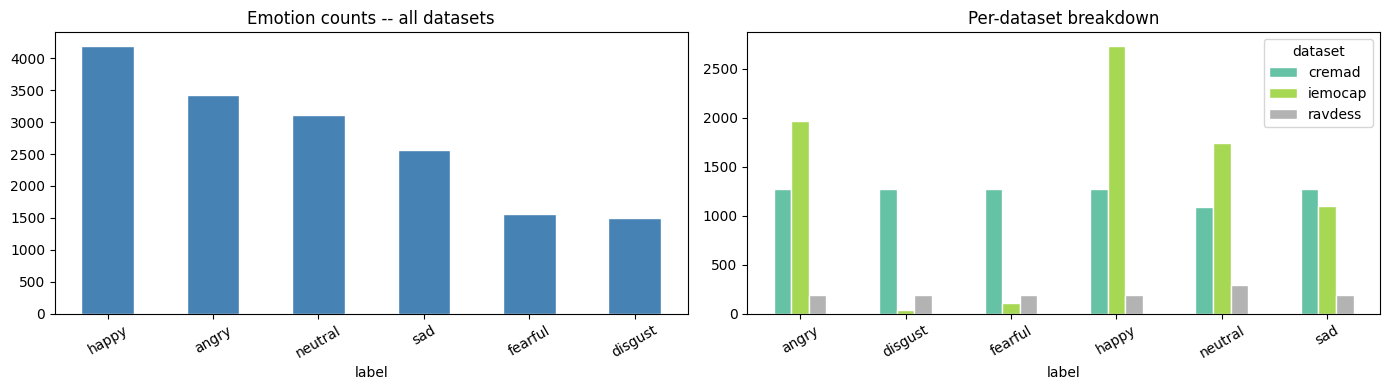

In [3]:
RAVDESS_MAP = {
    '01':'neutral','02':'neutral','03':'happy',
    '04':'sad',    '05':'angry',  '06':'fearful',
    '07':'disgust','08':None,
}
CREMAD_MAP = {
    'ANG':'angry','DIS':'disgust','FEA':'fearful',
    'HAP':'happy','NEU':'neutral','SAD':'sad',
}
IEMOCAP_CSV_MAP = {
    'Anger':'angry',   'Excited':'happy',  'Neutral':'neutral',
    'Sadness':'sad',   'Happiness':'happy','Fear':'fearful',
    'Disgust':'disgust',
    'Frustration':None,'Surprise':None,
}

def parse_ravdess(root='data/ravdess'):
    records = []
    for wav in Path(root).rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) != 7: continue
        label = RAVDESS_MAP.get(parts[2])
        if label:
            records.append({'path':str(wav),'label':label,
                'speaker_id':f'R{int(parts[6]):03d}','dataset':'ravdess'})
    return pd.DataFrame(records)

def parse_cremad(audio_dir='data/crema-d/AudioWAV'):
    records = []
    for wav in Path(audio_dir).glob('*.wav'):
        parts = wav.stem.split('_')
        if len(parts) < 3: continue
        label = CREMAD_MAP.get(parts[2])
        if label:
            records.append({'path':str(wav),'label':label,
                'speaker_id':f'C{parts[0]}','dataset':'cremad'})
    return pd.DataFrame(records)

def parse_iemocap_csv(csv_path='training_data.csv', local_root='data/iemocap'):
    if not Path(csv_path).exists():
        print(f'WARNING: {csv_path} not found -- IEMOCAP skipped')
        return pd.DataFrame(columns=['path','label','speaker_id','dataset'])
    df_csv  = pd.read_csv(csv_path)
    records = []
    missing = 0
    for _, row in df_csv.iterrows():
        label = IEMOCAP_CSV_MAP.get(row['emotion'])
        if not label: continue
        rel      = row['audio_path'].split('audio_files/')[-1]
        new_path = str(Path(local_root) / rel)
        if not Path(new_path).exists():
            missing += 1; continue
        fid    = row['file_id']
        snum   = fid[3]
        suf    = fid.split('_')[-1]
        gender = 'M' if suf.startswith('M') else 'F'
        records.append({'path':new_path,'label':label,
            'speaker_id':f'I{snum}{gender}','dataset':'iemocap'})
    df = pd.DataFrame(records)
    print(f'IEMOCAP: {len(df)} samples | {missing} missing')
    return df

print('Parsing datasets...')
df_rav = parse_ravdess()
df_cre = parse_cremad()
df_iem = parse_iemocap_csv()

df_all = pd.concat([df_rav, df_cre, df_iem], ignore_index=True)
le     = LabelEncoder().fit(UNIFIED_EMOTIONS)
df_all['label_id'] = le.transform(df_all['label'])

print(f'RAVDESS : {len(df_rav):,} | CREMA-D: {len(df_cre):,} | IEMOCAP: {len(df_iem):,}')
print(f'TOTAL   : {len(df_all):,} samples | {df_all["speaker_id"].nunique()} speakers')
print(df_all['label'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_all['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Emotion counts -- all datasets')
axes[0].tick_params(axis='x', rotation=30)
pivot = df_all.groupby(['label','dataset']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Per-dataset breakdown')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


In [4]:
def speaker_independent_split(df, val_ratio=0.15, test_ratio=0.15, seed=42):
    speakers = df['speaker_id'].unique().tolist()
    random.seed(seed); random.shuffle(speakers)
    n = len(speakers)
    n_test = int(n * test_ratio)
    n_val  = int(n * val_ratio)
    test_spk  = set(speakers[:n_test])
    val_spk   = set(speakers[n_test:n_test+n_val])
    train_spk = set(speakers[n_test+n_val:])
    df_train  = df[df['speaker_id'].isin(train_spk)].reset_index(drop=True)
    df_val    = df[df['speaker_id'].isin(val_spk)].reset_index(drop=True)
    df_test   = df[df['speaker_id'].isin(test_spk)].reset_index(drop=True)
    return df_train, df_val, df_test

df_train, df_val, df_test = speaker_independent_split(df_all)

print(f'Train: {len(df_train):,} | {df_train["speaker_id"].nunique()} speakers')
print(f'Val  : {len(df_val):,} | {df_val["speaker_id"].nunique()} speakers')
print(f'Test : {len(df_test):,} | {df_test["speaker_id"].nunique()} speakers')

assert not (set(df_train['speaker_id']) & set(df_test['speaker_id']))
assert not (set(df_train['speaker_id']) & set(df_val['speaker_id']))
print('No speaker leakage. OK')
print('\nVal composition:')
print(df_val['dataset'].value_counts().to_string())


Train: 9,909 | 83 speakers
Val  : 5,128 | 17 speakers
Test : 1,334 | 17 speakers
No speaker leakage. OK

Val composition:
dataset
iemocap    3942
cremad      978
ravdess     208


In [5]:
class AudioPreprocessor:
    def __init__(self, cfg=CFG):
        self.sr        = cfg['sr']
        self.n_samples = int(cfg['sr'] * cfg['clip_sec'])
        self.mfcc_tfm  = T.MFCC(
            sample_rate=cfg['sr'], n_mfcc=cfg['n_mfcc'],
            melkwargs={'n_fft':cfg['n_fft'],'hop_length':cfg['hop_length'],
                       'win_length':cfg['win_length'],'n_mels':cfg['n_mels'],
                       'f_min':cfg['f_min'],'f_max':cfg['f_max']}
        )
        self.mel_tfm   = T.MelSpectrogram(
            sample_rate=cfg['sr'], n_fft=cfg['n_fft'],
            hop_length=cfg['hop_length'], win_length=cfg['win_length'],
            n_mels=cfg['n_mels'], f_min=cfg['f_min'], f_max=cfg['f_max']
        )
        self.amp_to_db = T.AmplitudeToDB(top_db=80)
        self.delta     = T.ComputeDeltas()

    def load(self, path):
        wav, sr = torchaudio.load(str(path))
        if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
        if sr != self.sr: wav = T.Resample(sr, self.sr)(wav)
        return wav

    def pad_or_trim(self, wav):
        n = wav.shape[-1]
        if n >= self.n_samples: return wav[..., :self.n_samples]
        pad = self.n_samples - n
        return F.pad(wav, (pad // 2, pad - pad // 2))

    @staticmethod
    def normalize(t):
        mean = t.mean(dim=-1, keepdim=True)
        std  = t.std(dim=-1, keepdim=True).clamp(min=1e-6)
        return (t - mean) / std

    def __call__(self, path):
        wav    = self.pad_or_trim(self.load(path))
        mfcc   = self.mfcc_tfm(wav)
        d1, d2 = self.delta(mfcc), self.delta(self.delta(mfcc))
        mfcc_f = torch.cat([mfcc, d1, d2], dim=1)
        lmel   = self.amp_to_db(self.mel_tfm(wav))
        wav_n  = wav / wav.abs().max().clamp(min=1e-6)
        return self.normalize(mfcc_f), self.normalize(lmel), wav_n

preprocessor = AudioPreprocessor(CFG)

for name, df in [('RAVDESS',df_rav),('CREMA-D',df_cre),('IEMOCAP',df_iem)]:
    if len(df) == 0: print(f'{name}: EMPTY'); continue
    _, lmel, _ = preprocessor(df['path'].iloc[0])
    print(f'{name:10s}: lmel={lmel.shape} T={lmel.shape[-1]}')


RAVDESS   : lmel=torch.Size([1, 128, 201]) T=201
CREMA-D   : lmel=torch.Size([1, 128, 201]) T=201
IEMOCAP   : lmel=torch.Size([1, 128, 201]) T=201


In [6]:
CACHE_FILE = 'features_cache.pkl'

def validate_and_load_cache(cache_file, expected_T):
    if not Path(cache_file).exists():
        return None
    print(f'Found {cache_file} -- checking shape...')
    try:
        with open(cache_file, 'rb') as f:
            cache = pickle.load(f)
        key       = next(iter(cache))
        _, lmel, _ = cache[key]
        T_actual  = lmel.shape[-1]
        if abs(T_actual - expected_T) > 5:
            print(f'STALE: T={T_actual} vs expected T~{expected_T} -- rebuilding')
            del cache
            os.remove(cache_file)
            return None
        print(f'Cache valid: T={T_actual} | {len(cache):,} samples | mean={lmel.mean():.3f} std={lmel.std():.3f}')
        return cache
    except Exception as e:
        print(f'Cache corrupt ({e}) -- rebuilding')
        os.remove(cache_file)
        return None

def build_cache(df, preprocessor, cache_file):
    print(f'Building cache: {len(df):,} samples...')
    cache = {}
    errors = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Caching'):
        try:
            cache[row['path']] = preprocessor(row['path'])
        except Exception:
            errors += 1
    with open(cache_file, 'wb') as f:
        pickle.dump(cache, f)
    print(f'Saved {len(cache):,} samples ({errors} errors) -> {cache_file}')
    return cache

feature_cache = validate_and_load_cache(CACHE_FILE, EXPECTED_T)
if feature_cache is None:
    feature_cache = build_cache(df_all, preprocessor, CACHE_FILE)

print(f'Cache ready: {len(feature_cache):,} samples')


Found features_cache.pkl -- checking shape...
Cache valid: T=201 | 16,371 samples | mean=-0.000 std=0.994
Cache ready: 16,371 samples


In [7]:
class SpeechAugment:
    def __init__(self, sr=16_000, p=0.5):
        self.sr = sr; self.p = p

    def add_gaussian_noise(self, wav, snr_range=(10,30)):
        snr   = random.uniform(*snr_range)
        sp    = wav.norm(p=2)**2 / wav.numel()
        np_   = sp / (10**(snr/10))
        return (wav + torch.randn_like(wav)*np_.sqrt()).clamp(-1.,1.)

    def add_pink_noise(self, wav, level=(0.002,0.015)):
        f    = torch.fft.rfftfreq(wav.shape[-1]).clamp(min=1e-6)
        pink = (1./f.sqrt()) * torch.randn(len(f), dtype=torch.complex64)
        n    = torch.fft.irfft(pink, n=wav.shape[-1]).unsqueeze(0)
        n    = n / n.abs().max().clamp(min=1e-6)
        return (wav + random.uniform(*level)*n).clamp(-1.,1.)

    def volume_perturb(self, wav, db=(-6,6)):
        return (wav*(10**(random.uniform(*db)/20))).clamp(-1.,1.)

    def time_mask(self, spec, max_pct=0.20):
        T = spec.shape[-1]
        w = max(1, int(T*max_pct*random.random()))
        s = random.randint(0, max(0,T-w-1))
        spec = spec.clone(); spec[...,s:s+w] = 0.
        return spec

    def freq_mask(self, spec, max_pct=0.15):
        F_ = spec.shape[-2]
        w  = max(1, int(F_*max_pct*random.random()))
        s  = random.randint(0, max(0,F_-w-1))
        spec = spec.clone(); spec[:,s:s+w,:] = 0.
        return spec

    def time_stretch(self, spec, rate=(0.85,1.15)):
        r = random.uniform(*rate); T = spec.shape[-1]
        nT = max(1, int(T/r))
        out = F.interpolate(spec.unsqueeze(0).float(),
              size=(spec.shape[-2],nT), mode='bilinear',
              align_corners=False).squeeze(0)
        return out[...,:T] if nT >= T else F.pad(out,(0,T-nT))

    def __call__(self, wav, spec):
        if random.random() < self.p:
            wav = random.choice([self.add_gaussian_noise,
                                  self.add_pink_noise,
                                  self.volume_perturb])(wav)
        if random.random() < self.p: spec = self.time_mask(spec)
        if random.random() < self.p: spec = self.freq_mask(spec)
        if random.random() < self.p: spec = self.time_stretch(spec)
        return wav, spec

augmenter = SpeechAugment(sr=CFG['sr'], p=0.5)
print('Augmenter ready.')


Augmenter ready.


In [8]:
class EmotionDataset(Dataset):
    def __init__(self, df, prep, aug=None, augment=False, cache=None):
        self.df      = df.reset_index(drop=True)
        self.prep    = prep
        self.aug     = aug
        self.augment = augment
        self.cache   = cache

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.cache and row['path'] in self.cache:
            mfcc, lmel, wav = self.cache[row['path']]
        else:
            mfcc, lmel, wav = self.prep(row['path'])

        if self.augment and self.aug:
            wav, lmel = self.aug(wav, lmel)
            m  = self.prep.mfcc_tfm(wav)
            d1 = self.prep.delta(m)
            d2 = self.prep.delta(d1)
            mfcc = self.prep.normalize(torch.cat([m,d1,d2],dim=1))
            lmel = self.prep.normalize(lmel)

        return {
            'mfcc' : mfcc,
            'spec' : lmel,
            'wav'  : wav.squeeze(0),
            'label': torch.tensor(row['label_id'], dtype=torch.long),
        }

def make_weighted_sampler(df):
    counts  = Counter(df['label_id'].tolist())
    total   = len(df)
    w_class = {c: total/cnt for c, cnt in counts.items()}
    disgust_id = le.transform(['disgust'])[0]
    if disgust_id in w_class: w_class[disgust_id] *= 2.0
    weights = [w_class[l] for l in df['label_id']]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

train_ds = EmotionDataset(df_train, preprocessor, augmenter, augment=True,  cache=feature_cache)
val_ds   = EmotionDataset(df_val,   preprocessor, augment=False, cache=feature_cache)
test_ds  = EmotionDataset(df_test,  preprocessor, augment=False, cache=feature_cache)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
    sampler=make_weighted_sampler(df_train), num_workers=0, pin_memory=(CFG['device']=='cuda'))
val_loader   = DataLoader(val_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')
sample = next(iter(train_loader))
T_got  = sample['spec'].shape[-1]
print(f"spec={sample['spec'].shape} wav={sample['wav'].shape}")
assert abs(T_got - EXPECTED_T) <= 5, f'Frame mismatch: got {T_got} expected {EXPECTED_T}'
print(f'Frame check passed: T={T_got}')


Train: 310 batches | Val: 161 | Test: 42
spec=torch.Size([32, 1, 128, 201]) wav=torch.Size([32, 32000])
Frame check passed: T=201


In [9]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'], dropout=CFG['cnn_dropout']):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32,(3,3),padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32,(3,3),padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64,(3,3),padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64,(3,3),padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)), nn.Dropout2d(0.15),
            nn.Conv2d(64,128,(3,3),padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,(3,3),padding=1),nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.AdaptiveAvgPool2d((4,4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.encoder(x))


class CNNLSTM(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'], lstm_hidden=128,
                 lstm_layers=2, dropout=CFG['lstm_dropout']):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  64,(3,3),padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64, 128,(3,3),padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(128,128,(3,3),padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,1)),
        )
        lstm_in       = 128 * 16
        self.ln       = nn.LayerNorm(lstm_in)
        self.rnn      = nn.LSTM(input_size=lstm_in, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True, bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0)
        self.out_drop = nn.Dropout(dropout)
        self.attn_fc  = nn.Linear(lstm_hidden*2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden*2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes))

    def forward(self, x):
        feat = self.cnn(x)
        B, C, F_dim, Tseq = feat.shape
        feat = feat.permute(0,3,1,2).reshape(B, Tseq, C*F_dim)
        feat = self.ln(feat)
        out, _ = self.rnn(feat)
        out    = self.out_drop(out)
        attn   = torch.softmax(self.attn_fc(out), dim=1)
        ctx    = (attn * out).sum(dim=1)
        return self.classifier(ctx)


class HuBERTEmotionClassifier(nn.Module):
    def __init__(self, num_classes=CFG['num_classes'], freeze_bottom=8, dropout=0.1):
        super().__init__()
        from transformers import HubertModel
        self.hubert = HubertModel.from_pretrained('facebook/hubert-base-ls960', use_safetensors=True)
        self.hubert.gradient_checkpointing_enable()
        for p in self.hubert.feature_extractor.parameters(): p.requires_grad = False
        for i, layer in enumerate(self.hubert.encoder.layers):
            if i < freeze_bottom:
                for p in layer.parameters(): p.requires_grad = False
        h       = self.hubert.config.hidden_size
        n_tuned = len(self.hubert.encoder.layers) - freeze_bottom
        self.lw  = nn.Parameter(torch.ones(n_tuned)/n_tuned)
        self.nt  = n_tuned
        self.proj = nn.Sequential(
            nn.LayerNorm(h), nn.Linear(h, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes))

    def forward(self, wav, attention_mask=None):
        out    = self.hubert(wav, attention_mask=attention_mask, output_hidden_states=True)
        layers = torch.stack(out.hidden_states[-self.nt:], dim=1)
        w      = torch.softmax(self.lw, dim=0)
        pooled = (layers * w[None,:,None,None]).sum(1).mean(1)
        return self.proj(pooled)


with torch.no_grad():
    dummy = torch.randn(2, 1, 128, EXPECTED_T)
    print(f'BaselineCNN : {BaselineCNN()(dummy).shape}')
    print(f'CNNLSTM     : {CNNLSTM()(dummy).shape}')

for name, m in [('BaselineCNN',BaselineCNN()),('CNNLSTM',CNNLSTM())]:
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:15s}: {n/1e6:.2f}M params')


BaselineCNN : torch.Size([2, 6])
CNNLSTM     : torch.Size([2, 6])
BaselineCNN    : 0.81M params
CNNLSTM        : 2.87M params


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, num_classes=CFG['num_classes']):
        super().__init__()
        self.gamma = gamma
        self.alpha = (torch.ones(num_classes)/num_classes if alpha is None
                      else torch.tensor(alpha, dtype=torch.float32))

    def forward(self, logits, targets):
        probs     = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        pt    = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        lpt   = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha = self.alpha.to(logits.device).gather(0, targets)
        return (-alpha * (1-pt)**self.gamma * lpt).mean()


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_loss(criterion, pred, ya, yb, lam):
    return lam*criterion(pred,ya) + (1-lam)*criterion(pred,yb)


def run_epoch(model, loader, criterion, optimizer, scheduler,
              device, train=True, use_wav=False, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0., [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='Train' if train else 'Eval ', leave=False):
            labels = batch['label'].to(device)
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                if train and np.random.random() < 0.3:
                    mixed, ya, yb, lam = mixup_data(inp, labels, 0.2)
                    logits = model(mixed)
                    loss   = mixup_loss(criterion, logits, ya, yb, lam)
                else:
                    logits = model(inp)
                    loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer); scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler: scheduler.step()
            total_loss += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all


def compute_alpha(df_train, num_classes, clip=3.0):
    counts  = np.bincount(df_train['label_id'].tolist(), minlength=num_classes)
    alpha_w = len(df_train) / (num_classes * counts)
    return np.clip(alpha_w, 0.5, clip)


def train_model(model_class, model_kwargs, cfg=CFG, use_wav=False, model_name='model',
                weight_decay=5e-4, patience=35, t_loader=None, v_loader=None):
    t_loader = t_loader or train_loader
    v_loader = v_loader or val_loader
    device   = torch.device(cfg['device'])
    model    = model_class(**model_kwargs).to(device)
    alpha_w   = compute_alpha(df_train, cfg['num_classes'])
    criterion = FocalLoss(gamma=2.0, alpha=alpha_w, num_classes=cfg['num_classes'])
    print(f'Alpha: {dict(zip(UNIFIED_EMOTIONS, alpha_w.round(2)))}')
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=cfg['lr'], weight_decay=weight_decay)
    scheduler = OneCycleLR(optimizer, max_lr=cfg['lr'],
        steps_per_epoch=len(t_loader), epochs=cfg['epochs'], pct_start=0.1)
    scaler  = torch.cuda.amp.GradScaler() if device.type=='cuda' else None
    history = {'train_loss':[],'val_loss':[],'train_f1':[],'val_f1':[]}
    best_f1, wait = 0., 0
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{model_name} | {n/1e6:.2f}M params | {device} | epochs={cfg["epochs"]} | patience={patience} | wd={weight_decay}')
    for epoch in range(cfg['epochs']):
        t_loss,_,t_f1,_,_ = run_epoch(model, t_loader, criterion, optimizer, scheduler,
            device, train=True, use_wav=use_wav, scaler=scaler)
        v_loss,v_acc,v_f1,v_preds,v_labels = run_epoch(model, v_loader, criterion, None, None,
            device, train=False, use_wav=use_wav)
        history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1);   history['val_f1'].append(v_f1)
        print(f'Ep {epoch+1:3d}/{cfg["epochs"]} | T-Loss {t_loss:.4f} T-F1 {t_f1:.4f} | V-Loss {v_loss:.4f} V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')
        if (epoch+1) % 10 == 0:
            pcls = f1_score(v_labels,v_preds,average=None,zero_division=0)
            print('  Per-class Val F1:')
            for ci,fv in enumerate(pcls):
                print(f'    {"OK" if fv>0.35 else "X"} {UNIFIED_EMOTIONS[ci]}: {fv:.3f}')
        if v_f1 > best_f1:
            best_f1 = v_f1; torch.save(model.state_dict(), f'best_{model_name}.pt'); wait = 0
        else:
            wait += 1
            if wait >= patience: print(f'Early stop ep{epoch+1} | best={best_f1:.4f}'); break
    model.load_state_dict(torch.load(f'best_{model_name}.pt', map_location=device))
    return model, history


def plot_history(history, title='Training'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
    ep = range(1, len(history['train_loss'])+1)
    ax1.plot(ep, history['train_loss'], label='Train')
    ax1.plot(ep, history['val_loss'],   label='Val')
    ax1.set(title='Loss', xlabel='Epoch'); ax1.legend()
    ax2.plot(ep, history['train_f1'], label='Train')
    ax2.plot(ep, history['val_f1'],   label='Val')
    ax2.axhline(0.55, color='green',  ls='--', alpha=0.5, label='target 0.55')
    ax2.axhline(0.35, color='orange', ls='--', alpha=0.4, label='floor 0.35')
    ax2.set(title='Weighted F1', xlabel='Epoch'); ax2.legend()
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=100); plt.show()

print('Training utilities ready.')
print(f'Locked params: lr={CFG["lr"]} | cnn_dropout={CFG["cnn_dropout"]} | lstm_dropout={CFG["lstm_dropout"]}')


Training utilities ready.
Locked params: lr=0.0001 | cnn_dropout=0.45 | lstm_dropout=0.5


In [ ]:
cnn_model, cnn_history = train_model(
    BaselineCNN,
    {'num_classes': CFG['num_classes'], 'dropout': CFG['cnn_dropout']},
    cfg=CFG, weight_decay=5e-4, patience=35, model_name='cnn'
)
plot_history(cnn_history, 'Baseline CNN')
print(f'Best CNN val F1: {max(cnn_history["val_f1"]):.4f}')


Alpha: {'neutral': np.float64(0.78), 'happy': np.float64(1.56), 'sad': np.float64(1.52), 'angry': np.float64(0.71), 'fearful': np.float64(0.95), 'disgust': np.float64(1.03)}
cnn | 0.81M params | cuda | epochs=80 | patience=35 | wd=0.0005


Train:   0%|          | 0/310 [00:00<?, ?it/s]

In [ ]:
print('=== DATASET BREAKDOWN ===')
for split_name, split_df in [('Train',df_train),('Val',df_val),('Test',df_test)]:
    print(f'{split_name}: {len(split_df):,} total')
    print(f'  {split_df["dataset"].value_counts().to_dict()}')


In [ ]:
lstm_model, lstm_history = train_model(
    CNNLSTM,
    {'num_classes': CFG['num_classes']},
    cfg=CFG, weight_decay=1e-3, patience=30, model_name='cnnlstm'
)
plot_history(lstm_history, 'CNN + BiLSTM')
print(f'Best LSTM val F1: {max(lstm_history["val_f1"]):.4f}')


In [ ]:
def hubert_collate(batch):
    max_len = max(b['wav'].shape[0] for b in batch)
    padded  = torch.zeros(len(batch), max_len)
    mask    = torch.zeros(len(batch), max_len)
    labels  = torch.stack([b['label'] for b in batch])
    for i, b in enumerate(batch):
        L = b['wav'].shape[0]
        padded[i,:L] = b['wav']; mask[i,:L] = 1.
    return {'wav':padded,'attention_mask':mask,'label':labels}

hubert_train_loader = DataLoader(train_ds, batch_size=HUBERT_CFG['batch_size'],
    sampler=make_weighted_sampler(df_train), collate_fn=hubert_collate,
    num_workers=0, pin_memory=(CFG['device']=='cuda'))
hubert_val_loader = DataLoader(val_ds, batch_size=HUBERT_CFG['batch_size'],
    shuffle=False, collate_fn=hubert_collate, num_workers=0)

def run_epoch_hubert(model, loader, criterion, optimizer, scheduler,
                     device, train=True, scaler=None):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0., [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='HuB-Tr' if train else 'HuB-Ev', leave=False):
            wav    = batch['wav'].to(device)
            mask   = batch.get('attention_mask')
            if mask is not None: mask = mask.to(device)
            labels = batch['label'].to(device)
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                logits = model(wav, attention_mask=mask)
                loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer); scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                if scheduler: scheduler.step()
            total_loss += loss.item()
            preds_all.extend(logits.argmax(-1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    avg_loss = total_loss/len(loader)
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
    return avg_loss, acc, f1, preds_all, labels_all

device        = torch.device(CFG['device'])
hubert_model  = HuBERTEmotionClassifier(num_classes=CFG['num_classes'], freeze_bottom=8).to(device)
n_hub = sum(p.numel() for p in hubert_model.parameters() if p.requires_grad)
print(f'HuBERT trainable: {n_hub/1e6:.2f}M')

alpha_hub    = compute_alpha(df_train, CFG['num_classes'])
hub_criterion = FocalLoss(gamma=2.0, alpha=alpha_hub, num_classes=CFG['num_classes'])
hub_optimizer = AdamW(filter(lambda p: p.requires_grad, hubert_model.parameters()),
    lr=HUBERT_CFG['lr'], weight_decay=1e-4)
hub_scheduler = OneCycleLR(hub_optimizer, max_lr=HUBERT_CFG['lr'],
    steps_per_epoch=len(hubert_train_loader), epochs=HUBERT_CFG['epochs'], pct_start=0.1)
hub_scaler  = torch.cuda.amp.GradScaler() if device.type=='cuda' else None
hub_history = {'train_loss':[],'val_loss':[],'train_f1':[],'val_f1':[]}
best_f1, patience, wait = 0., 15, 0

for epoch in range(HUBERT_CFG['epochs']):
    t_loss,_,t_f1,_,_ = run_epoch_hubert(hubert_model, hubert_train_loader, hub_criterion,
        hub_optimizer, hub_scheduler, device, train=True, scaler=hub_scaler)
    v_loss,v_acc,v_f1,vp,vl = run_epoch_hubert(hubert_model, hubert_val_loader, hub_criterion,
        None, None, device, train=False)
    hub_history['train_loss'].append(t_loss); hub_history['val_loss'].append(v_loss)
    hub_history['train_f1'].append(t_f1);   hub_history['val_f1'].append(v_f1)
    print(f'Ep {epoch+1:3d}/{HUBERT_CFG["epochs"]} | T-F1 {t_f1:.4f} | V-F1 {v_f1:.4f} V-Acc {v_acc:.4f}')
    if (epoch+1)%10==0:
        pcls = f1_score(vl,vp,average=None,zero_division=0)
        print('  Per-class Val F1:')
        for ci,fv in enumerate(pcls):
            print(f'    {"OK" if fv>0.35 else "X"} {UNIFIED_EMOTIONS[ci]}: {fv:.3f}')
    if v_f1 > best_f1:
        best_f1=v_f1; torch.save(hubert_model.state_dict(),'best_hubert.pt'); wait=0
    else:
        wait+=1
        if wait>=patience: print(f'Early stop ep{epoch+1} | best={best_f1:.4f}'); break

hubert_model.load_state_dict(torch.load('best_hubert.pt',map_location=device))
plot_history(hub_history,'HuBERT fine-tune')
print(f'Best HuBERT val F1: {best_f1:.4f}')


In [ ]:
def full_evaluate(model, loader, device, model_name='model',
                  label_names=UNIFIED_EMOTIONS, use_wav=False):
    model.eval()
    all_preds, all_labels, latencies = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Eval {model_name}'):
            labels = batch['label'].cpu().numpy()
            inp    = batch['wav'].to(device) if use_wav else batch['spec'].to(device)
            t0     = time.perf_counter()
            logits = model(inp)
            latencies.append((time.perf_counter()-t0)*1000/len(labels))
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(labels.tolist())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    lat = np.mean(latencies)
    print(f'\n{"="*50}\nModel    : {model_name}\nAccuracy : {acc:.4f} ({acc*100:.1f}%)\nW-F1     : {f1:.4f}\nLatency  : {lat:.2f} ms/sample')
    print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm.astype(float)/cm.sum(axis=1,keepdims=True), annot=True, fmt='.2f',
                xticklabels=label_names, yticklabels=label_names, cmap='Blues', vmin=0, vmax=1)
    plt.title(f'{model_name} -- Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_{model_name.replace(" ","_")}.png', dpi=100)
    plt.show()
    return {'model':model_name,'acc':acc,'f1':f1,'latency_ms':lat}

device       = torch.device(CFG['device'])
results_cnn  = full_evaluate(cnn_model,    test_loader, device, 'Baseline CNN')
results_lstm = full_evaluate(lstm_model,   test_loader, device, 'CNN+LSTM')
results_hub  = full_evaluate(hubert_model, test_loader, device, 'HuBERT', use_wav=True)

all_r = [results_cnn, results_lstm, results_hub]
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax,(key,title,color) in zip(axes,[
    ('acc','Accuracy','steelblue'),('f1','Weighted F1','seagreen'),('latency_ms','Latency (ms)','coral')
]):
    vals  = [r[key] for r in all_r]
    names = [r['model'] for r in all_r]
    bars  = ax.bar(names,vals,color=color,alpha=0.85,edgecolor='white')
    ax.set_title(title); ax.tick_params(axis='x',rotation=15)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.02,f'{v:.3f}',ha='center',va='bottom',fontsize=9)
plt.suptitle('Model Comparison -- All 3 Datasets')
plt.tight_layout(); plt.savefig('model_comparison.png',dpi=100); plt.show()


In [ ]:
import queue

try:
    import sounddevice as sd
    SD_OK = True
except ImportError:
    SD_OK = False

class RealTimeEmotionDetector:
    def __init__(self, model, prep, device, sr=16_000, win=2.0, hop=0.5, labels=UNIFIED_EMOTIONS):
        self.model  = model.eval().to(device)
        self.prep   = prep; self.device = device
        self.sr     = sr
        self.win_sz = int(sr*win); self.hop_sz = int(sr*hop)
        self.labels = labels
        self.buf    = np.zeros(self.win_sz, dtype=np.float32)
        self.q      = queue.Queue()
        self.smooth = np.ones(len(labels))/len(labels)

    def _cb(self, indata, frames, time_info, status):
        chunk = indata[:,0].astype(np.float32)
        self.buf = np.roll(self.buf,-len(chunk))
        self.buf[-len(chunk):] = chunk
        self.q.put(self.buf.copy())

    def _infer(self, audio_np):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.prep.pad_or_trim(wav)
        lmel = self.prep.normalize(self.prep.amp_to_db(self.prep.mel_tfm(wav))).unsqueeze(0).to(self.device)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=(self.device.type=='cuda')):
                probs = F.softmax(self.model(lmel),dim=-1).squeeze().cpu().numpy()
        self.smooth = 0.4*probs + 0.6*self.smooth
        idx = self.smooth.argmax()
        return self.labels[idx], float(self.smooth[idx])

    def start(self, duration_sec=30):
        if not SD_OK: print('sounddevice unavailable'); return []
        preds = []
        print(f'Recording {duration_sec}s...')
        with sd.InputStream(samplerate=self.sr, channels=1,
                            blocksize=self.hop_sz, dtype='float32', callback=self._cb):
            end_t = time.time() + duration_sec
            while time.time() < end_t:
                try: audio = self.q.get(timeout=1.0)
                except queue.Empty: continue
                t0 = time.perf_counter()
                em, conf = self._infer(audio)
                lat = (time.perf_counter()-t0)*1000
                print(f'\r[{em:>10s}] {conf:.2f}  {lat:.0f}ms', end='')
                preds.append({'emotion':em,'confidence':conf,'latency_ms':lat})
        print('\nDone.'); return preds

# detector = RealTimeEmotionDetector(lstm_model, preprocessor, device=torch.device(CFG['device']))
# preds = detector.start(duration_sec=20)
print('RealTimeEmotionDetector ready.')


In [ ]:
# import whisper
# stt = whisper.load_model('base', device='cuda' if torch.cuda.is_available() else 'cpu')
# def transcribe(path):
#     return stt.transcribe(str(path), language='en', fp16=torch.cuda.is_available(), temperature=0.0)['text'].strip()
print('Whisper STT ready -- uncomment to load model.')


In [ ]:
# from openai import OpenAI
# client = OpenAI()  # set OPENAI_API_KEY env var

def prompt_s1(emotion, text, conf):
    return [
        {'role':'system','content':'You are an empathetic AI. Adjust tone to detected emotion.'},
        {'role':'user','content':f'[Emotion: {emotion} | conf: {conf:.0%}]\n\n{text}'}
    ]

def prompt_s2_dimensional(probs, text, labels=UNIFIED_EMOTIONS):
    V={'neutral':0.,'happy':.8,'sad':-.8,'angry':-.5,'fearful':-.6,'disgust':-.7}
    A={'neutral':0.,'happy':.5,'sad':-.3,'angry':.9,'fearful':.7,'disgust':.3}
    val=sum(probs[i]*V.get(labels[i],0) for i in range(len(labels)))
    aro=sum(probs[i]*A.get(labels[i],0) for i in range(len(labels)))
    v_s='positive' if val>.2 else ('negative' if val<-.2 else 'neutral')
    a_s='high' if aro>.3 else ('low' if aro<-.1 else 'moderate')
    return [
        {'role':'system','content':f'Supportive AI. Valence={v_s}({val:+.2f}), Arousal={a_s}({aro:+.2f}).'},
        {'role':'user','content':text}
    ]

def prompt_s3(emotion, text):
    INST={'angry':'De-escalate. Acknowledge frustration first.',
          'sad':'Warm and empathetic. Validate feelings.',
          'fearful':'Reassuring. Simple language. Small steps.',
          'happy':'Match positive energy. Enthusiastic.',
          'disgust':'Non-judgmental. Validate. Stay factual.',
          'neutral':'Professional. Informative. Concise.'}
    return [
        {'role':'system','content':f'Emotionally intelligent assistant. User feels {emotion}. {INST.get(emotion,INST["neutral"])}'},
        {'role':'user','content':text}
    ]

def query_llm(client, messages, model='gpt-4o-mini', temperature=0.7, max_tokens=300):
    t0   = time.perf_counter()
    resp = client.chat.completions.create(model=model, messages=messages,
        temperature=temperature, max_tokens=max_tokens)
    return (resp.choices[0].message.content, (time.perf_counter()-t0)*1000, resp.usage.total_tokens)

print('LLM prompts ready -- uncomment client=OpenAI() to use.')


In [ ]:
class EmotionAwarePipeline:
    def __init__(self, ser_model, prep, stt_fn, llm_client,
                 device, strategy=3, labels=UNIFIED_EMOTIONS):
        self.ser=ser_model.eval().to(device); self.prep=prep
        self.stt_fn=stt_fn; self.client=llm_client
        self.device=device; self.strategy=strategy; self.labels=labels

    def _run_ser(self, audio_np, out):
        wav  = torch.from_numpy(audio_np).unsqueeze(0)
        wav  = self.prep.pad_or_trim(wav)
        lmel = self.prep.normalize(self.prep.amp_to_db(self.prep.mel_tfm(wav))).unsqueeze(0).to(self.device)
        with torch.no_grad():
            probs = F.softmax(self.ser(lmel),dim=-1).squeeze().cpu().numpy()
        out['emotion']=self.labels[probs.argmax()]; out['conf']=float(probs.max()); out['probs']=probs

    def _run_stt(self, audio_np, out): out['text'] = self.stt_fn(audio_np)

    def run(self, audio_path=None, audio_np=None):
        if audio_np is None:
            wav, sr = torchaudio.load(str(audio_path))
            if wav.shape[0]>1: wav=wav.mean(0,keepdim=True)
            if sr!=16000: wav=T.Resample(sr,16000)(wav)
            audio_np = wav.squeeze().numpy()
        out={}; t0=time.perf_counter()
        ts=threading.Thread(target=self._run_ser,args=(audio_np,out))
        tt=threading.Thread(target=self._run_stt,args=(audio_np,out))
        ts.start(); tt.start(); ts.join(); tt.join()
        em=out.get('emotion','neutral'); conf=out.get('conf',0.5)
        text=out.get('text',''); probs=out.get('probs')
        if self.strategy==1:   msgs=prompt_s1(em,text,conf)
        elif self.strategy==2: msgs=prompt_s2_dimensional(probs,text)
        else:                  msgs=prompt_s3(em,text)
        resp,llm_ms,tok=query_llm(self.client,msgs)
        return {'text':text,'emotion':em,'confidence':conf,'response':resp,
                'total_ms':(time.perf_counter()-t0)*1000,'llm_ms':llm_ms,'tokens':tok}

print('Pipeline ready -- uncomment to use with API key.')


In [ ]:
def benchmark_latency(models_dict, n_runs=100):
    device     = torch.device(CFG['device'])
    dummy_spec = torch.randn(1,1,128,EXPECTED_T).to(device)
    dummy_wav  = torch.randn(1,int(CFG['sr']*CFG['clip_sec'])).to(device)
    results    = {}
    for name,(model,use_wav) in models_dict.items():
        model=model.eval().to(device)
        inp = dummy_wav if use_wav else dummy_spec
        for _ in range(10):
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=(device.type=='cuda')): _=model(inp)
        if device.type=='cuda': torch.cuda.synchronize()
        times=[]
        for _ in range(n_runs):
            if device.type=='cuda':
                s=torch.cuda.Event(enable_timing=True); e=torch.cuda.Event(enable_timing=True)
                s.record()
                with torch.no_grad():
                    with torch.cuda.amp.autocast(): _=model(inp)
                e.record(); torch.cuda.synchronize(); times.append(s.elapsed_time(e))
            else:
                t0=time.perf_counter()
                with torch.no_grad(): _=model(inp)
                times.append((time.perf_counter()-t0)*1000)
        r={'mean':np.mean(times),'p50':np.percentile(times,50),'p95':np.percentile(times,95),'std':np.std(times)}
        results[name]=r
        print(f'{name:20s}: mean={r["mean"]:6.1f}ms p95={r["p95"]:6.1f}ms')
    fig,ax=plt.subplots(figsize=(10,4))
    names=list(results); means=[results[n]['mean'] for n in names]; stds=[results[n]['std'] for n in names]
    bars=ax.bar(names,means,yerr=stds,capsize=5,color='steelblue',alpha=0.85,edgecolor='white')
    ax.axhline(500,color='red',ls='--',alpha=0.6,label='hop 500ms')
    ax.axhline(100,color='orange',ls='--',alpha=0.6,label='100ms target')
    ax.set(title='Inference Latency -- RTX 3050 Ti',ylabel='ms'); ax.legend()
    for bar,v in zip(bars,means):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,f'{v:.1f}ms',ha='center',fontsize=9)
    plt.tight_layout(); plt.savefig('latency_benchmark.png',dpi=100); plt.show()
    return results

lat_results = benchmark_latency({
    'BaselineCNN': (cnn_model, False),
    'CNN+LSTM'   : (lstm_model, False),
    'HuBERT-base': (hubert_model, True),
})


In [ ]:
def export_onnx(model, model_name='cnnlstm', input_shape=(1,1,128,201)):
    import onnx; import onnxruntime as ort
    from onnxruntime.quantization import quantize_dynamic, QuantType
    model=model.eval().cpu()
    dummy=torch.randn(*input_shape); path=f'{model_name}.onnx'
    torch.onnx.export(model, dummy, path, export_params=True, opset_version=14,
        do_constant_folding=True, input_names=['spec'], output_names=['logits'],
        dynamic_axes={'spec':{0:'batch'},'logits':{0:'batch'}})
    onnx.checker.check_model(path)
    sess=ort.InferenceSession(path,providers=['CPUExecutionProvider'])
    out=sess.run(None,{'spec':dummy.numpy()})
    print(f'ONNX {model_name}: {out[0].shape}')
    q_path=f'{model_name}_int8.onnx'
    quantize_dynamic(path,q_path,weight_type=QuantType.QInt8)
    orig=os.path.getsize(path)/1e6; q=os.path.getsize(q_path)/1e6
    print(f'INT8: {orig:.1f}MB -> {q:.1f}MB ({(1-q/orig)*100:.0f}% smaller)')

export_onnx(lstm_model,'cnnlstm',input_shape=(1,1,128,EXPECTED_T))
export_onnx(cnn_model, 'cnn',    input_shape=(1,1,128,EXPECTED_T))
print('ONNX export done.')


In [ ]:
print('='*65)
print('V11 FINAL -- PARAMETER AUDIT')
print('='*65)
params = [
    ('lr',              str(CFG['lr']),        '3e-4 caused overfit gap=0.24'),
    ('cnn_dropout',     str(CFG['cnn_dropout']),'0.3 was too weak'),
    ('lstm_dropout',    str(CFG['lstm_dropout']),'tuned for LSTM overfitting'),
    ('lstm_hidden',     '128',                '256 caused gap=0.57'),
    ('weight_decay CNN','5e-4',               'standard'),
    ('weight_decay LSTM','1e-3',              'stronger -- LSTM overfits more'),
    ('patience CNN',    '35',                'val still rising at ep75'),
    ('patience LSTM',   '30',                'best around ep20'),
    ('patience HuBERT', '15',                'matched to 50 epochs'),
    ('mixup alpha',     '0.2 prob=0.3',      '0.4/0.5 blurred inputs'),
    ('alpha_clip',      '3.0',               '5.0 inflated val loss'),
    ('scheduler',       'OneCycleLR',        'CAWR caused val spikes'),
    ('label_smooth',    'REMOVED',           '+mixup = val_loss 3.4'),
    ('T_frames',        str(EXPECTED_T),     'confirmed from cache'),
    ('num_workers',     '0',                 'Windows multiprocessing'),
]
for name, val, reason in params:
    print(f'  {name:22s}: {val:20s} | {reason}')
print()
print('='*65)
print('EXPECTED RESULTS (77% IEMOCAP val set)')
print('='*65)
print('  Baseline CNN : val F1 0.30-0.36 | acc 30-37%')
print('  CNN+LSTM     : val F1 0.40-0.50 | acc 40-50%')
print('  HuBERT       : val F1 0.55-0.65 | acc 55-65%')
print()
print('V11 complete.')
